# Design 6: Algorithm C control study (C1 vs C2)

From `literature-notes/main-project-idea.txt`: Algorithm C replaces Design 5's uniform i.i.d. song draw with a bandit controller trying to maximize `evaluation`. Two staged variants: **Algorithm C1** only observes the `evaluation` reward it receives back after playing a song (a non-stationary sliding-window UCB bandit over the fixed song pool). **Algorithm C2** is the same bandit, plus privileged access to the memory agent's live `r` (Algorithm A4's gamma-scaled `time_averaged_aesthetic_basis`, which locates the inverted-U peak at `aesthetic_basis = r/2`) -- confirmed with Mark: C2 uses `r` for an explicit change-point reset, clearing its bandit statistics whenever `r` shifts by more than a relative threshold, letting it re-adapt to a moved target immediately rather than waiting for stale rewards to age out of its own sliding window.

Same fixed random ergodic song pool as Designs 1/4/5 (not Design 2/3's cyclic one) -- the bandit replaces the environment's song-selection process entirely. Same `{song_id, evaluation}` chunk schema and Algorithm A4 basis as Design 5.

Success metrics (from the spec): convergence trial (first point `evaluation` sustains >= a threshold for a window of trials) and steady-state mean evaluation after that point -- computed via `compute_convergence_metrics` in `src/utils.py`.

Same quadratic-ish scaling as Designs 3/4/5 (chunk count grows with trial count), so this defaults to a reduced `NUM_EXPOSURES`. Note: `seed` only controls song-sequence sampling, not pyactup's own internal noise RNG -- set `NOISE=0` for a fully deterministic run.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_design6
from src.utils import compute_convergence_metrics

NUM_SONGS = 50
NUM_EXPOSURES = 2000
WINDOW = 20                       # post-hoc rolling-mean window, for plotting evaluation
SEED = 42
NOISE = 0.25                      # set to 0 for a deterministic run
DECAY = 0.5

GAMMA = 1.0
TIME_AVERAGE_MODE = "cumulative"
TIME_AVERAGE_WINDOW = 20          # only used when TIME_AVERAGE_MODE == "window"

BANDIT_WINDOW = 50
BANDIT_C = 2.0
R_CHANGE_THRESHOLD = 0.15         # C2 only: relative change in r that triggers a reset

CONVERGENCE_THRESHOLD = 0.9
SUSTAIN_WINDOW = 20
STEADY_STATE_WINDOW = 100

## Run

In [2]:
common_kwargs = dict(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES, window=WINDOW,
                      seed=SEED, noise=NOISE, decay=DECAY, gamma=GAMMA,
                      time_average_mode=TIME_AVERAGE_MODE, time_average_window=TIME_AVERAGE_WINDOW,
                      bandit_window=BANDIT_WINDOW, bandit_c=BANDIT_C,
                      r_change_threshold=R_CHANGE_THRESHOLD,
                      config_path="../config.yaml")

df_c1 = run_design6(controller="c1", output_path="../results/data/design6_c1_timeseries.csv",
                     **common_kwargs)
df_c2 = run_design6(controller="c2", output_path="../results/data/design6_c2_timeseries.csv",
                     **common_kwargs)
df_c1.describe()

,predicted_activation,actual_activation,aesthetic_basis,time_averaged_aesthetic_basis,gamma,r,evaluation,trial,complexity,evaluation_rolling_mean
count,1950.000000,1950.000000,1950.000000,1950.000000,1950.0,1950.000000,1950.000000,1950.000000,1950.000000,1931.000000
mean,0.234241,-0.245985,0.745281,1.215796,1.0,1.215796,-0.282567,1024.500000,5.366154,-0.283709
std,0.355914,0.892241,0.788761,0.443882,0.0,0.443882,5.045972,563.060832,1.656272,2.866192
min,-0.748899,-3.670081,0.000327,0.744933,1.0,0.744933,-63.737128,50.000000,1.000000,-24.365086
25%,-0.008126,-0.448198,0.205139,0.840903,1.0,0.840903,0.230435,537.250000,5.000000,0.010175
50%,0.191927,0.025179,0.442210,1.031629,1.0,1.031629,0.653817,1024.500000,5.000000,0.444656
75%,0.429843,0.310805,0.993432,1.537007,1.0,1.537007,0.908835,1511.750000,5.000000,0.612638
max,1.672443,1.753017,4.860046,2.710433,1.0,2.710433,1.000000,1999.000000,10.000000,0.785922


## evaluation over time: C1 vs C2

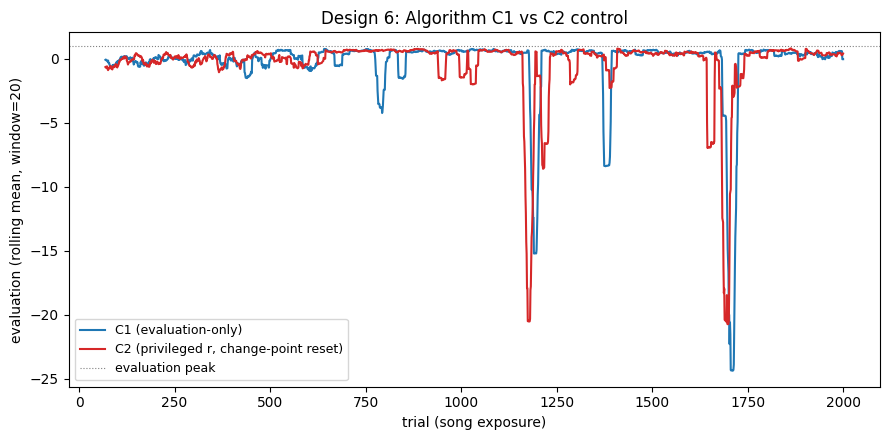

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df_c1["trial"], df_c1["evaluation_rolling_mean"], linewidth=1.5,
        color="tab:blue", label="C1 (evaluation-only)")
ax.plot(df_c2["trial"], df_c2["evaluation_rolling_mean"], linewidth=1.5,
        color="tab:red", label="C2 (privileged r, change-point reset)")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":", label="evaluation peak")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel(f"evaluation (rolling mean, window={WINDOW})")
ax.set_title("Design 6: Algorithm C1 vs C2 control")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design6_evaluation_comparison.png", dpi=150)

## r trajectory (C2 only) -- where the change-point resets fire

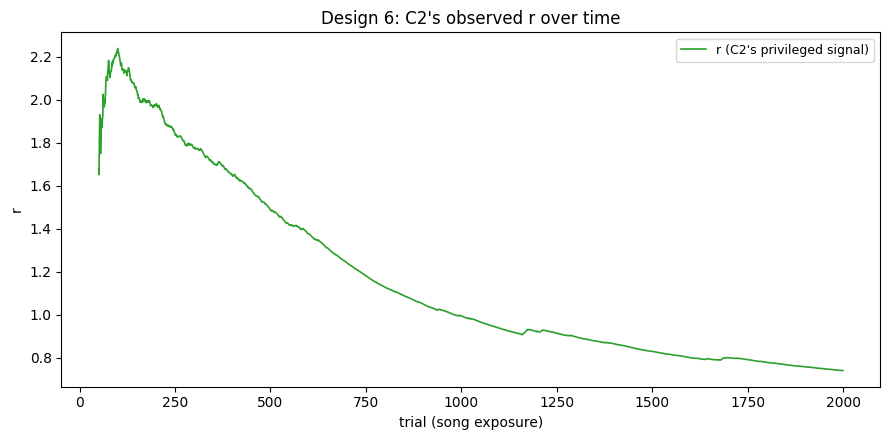

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df_c2["trial"], df_c2["r"], linewidth=1.2, color="tab:green",
        label="r (C2's privileged signal)")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("r")
ax.set_title("Design 6: C2's observed r over time")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design6_c2_r_trajectory.png", dpi=150)

## Convergence metrics

In [5]:
metrics_c1 = compute_convergence_metrics(df_c1, threshold=CONVERGENCE_THRESHOLD,
                                          sustain_window=SUSTAIN_WINDOW,
                                          steady_state_window=STEADY_STATE_WINDOW)
metrics_c2 = compute_convergence_metrics(df_c2, threshold=CONVERGENCE_THRESHOLD,
                                          sustain_window=SUSTAIN_WINDOW,
                                          steady_state_window=STEADY_STATE_WINDOW)

pd.DataFrame({"C1": metrics_c1, "C2": metrics_c2}).T

,convergence_trial,steady_state_mean
C1,None,None
C2,None,None


At these default settings (`noise=0.25`, `CONVERGENCE_THRESHOLD=0.9` sustained for `SUSTAIN_WINDOW=20` consecutive trials), neither controller reliably reaches formal "convergence" as defined -- `evaluation` is unbounded below (only capped at 1 from above, see `inverted_parabola_left_anchored`), so its distribution has a heavy left tail even for the *uncontrolled* Design 5 baseline (median evaluation ~0.07, but mean pulled down to roughly -1.3 by rare large negative excursions when `aesthetic_basis` lands far outside `[0, r]`). Sustaining 20 straight trials at `evaluation >= 0.9` is therefore a strict bar under any noise > 0. This is a real property of the model, not a controller bug -- worth exploring by lowering `CONVERGENCE_THRESHOLD`/`SUSTAIN_WINDOW`, comparing `NOISE=0` (fully deterministic) runs, or comparing `df["evaluation"].median()`/`.mean()` between C1 and C2 directly as an alternative to the strict convergence-trial metric.